In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from encoder_decoder import*
import matplotlib.pyplot as plt

# Check vocab and define encoding/decoding functions (from int to char and viceversa)
# Define the vocab and vocab_size

In [2]:
# first import the little dictionary frol it_es_cognates.txt

italian_words = []
spanish_words = []

with open("it_es_cognates.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        it, es = line.split(";") # words separated by ;
        italian_words.append(it.lower())
        spanish_words.append(es.lower())

# check the number of words in the list of cognates
print(len(italian_words), "pairs")
print(italian_words[:5], spanish_words[:5])

# find all characters appearing in the list of cognates
all_chars = set()
for word in spanish_words + italian_words:
    all_chars.update(word)
all_chars = sorted(all_chars)

# add the special caracters: pad, start of string, end of string, unknown
specials = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab = specials + all_chars

# build the dictionaries, just use the enumeration of vocab to assign an integer to every character
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# check the characters in the vocabulary, and its length
print("vocab: ", vocab)
print("vocab length:", len(vocab))

# test word size in the vocabulary (need to know the dimension of the words I am going to have in the model - by padding)
# I will add 2 or 3 just to be on the safe side for future additions to the dictionary, getting, say, to 20
print("Max length of spanish words: ", max(len(w) for w in spanish_words))
print("Max length of italian words: ", max(len(w) for w in italian_words))

def encode_source(word, max_len = 20):
    # input: no sos/eos needed
    ids = [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len] # use the char to int dictionary
    ids += [char_to_idx['<pad>']] * (max_len - len(ids)) # fill with '<pad>' until the prescribed length max_len
    return torch.tensor(ids)

def encode_target(word, max_len = 20):
    # output: needs sos/eos since decoder generates it step by step, they will replace two <pad> 
    ids = [char_to_idx['<sos>']] + [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len-2] + [char_to_idx['<eos>']]
    ids += [char_to_idx['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids) 

def decode_source(ids):
    
    ids_numpy = ids.numpy()
    chars = []
    for i in ids_numpy:
        ch = idx_to_char[i] # use the integer to char dictionary
        if ch == '<pad>':
            break  # padding marks the end of real content
        chars.append(ch)
    return ''.join(chars)

# test
print(encode_source('castoro'))
print(decode_source(encode_source('castoro'))) 
print(decode_source(encode_source('è'))) # check unknown characters


# now test the embedding
vocab_size = len(char_to_idx)
d_model = 32 # needs to be large enough but does not have to be larger than number of characters - in fact for LLMs it is smaller than the number of tokens
embed = nn.Embedding(vocab_size, d_model, padding_idx=char_to_idx['<pad>'])

print(embed(encode_source('castoro')))

1801 pairs
['a', 'acqua', 'acque', 'aeroporti', 'aeroporto'] ['a', 'agua', 'aguas', 'aeropuertos', 'aeropuerto']
vocab:  ['<pad>', '<sos>', '<eos>', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'á', 'é', 'ì', 'í', 'ñ', 'ó', 'ù', 'ú']
vocab length: 37
Max length of spanish words:  15
Max length of italian words:  15
tensor([ 6,  4, 21, 22, 17, 20, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0])
castoro
<unk>
tensor([[ 0.4196, -0.7013,  0.9290,  1.5304,  1.4382, -1.0096,  0.7361,  0.7021,
          0.9081, -1.3873,  0.4524,  0.1034,  0.3420, -1.3585,  2.6564,  0.1265,
         -0.1455,  0.5914, -0.1254,  1.8232,  1.7079,  1.1471,  0.6514,  0.7436,
          0.8764,  0.2527, -1.5352,  0.0091,  0.4562,  0.2932, -1.2446,  0.1761],
        [ 1.0649, -2.2137, -0.2624, -0.1810, -0.6495,  1.0874,  1.8223,  0.3551,
          1.2524, -1.1086,  0.8603, -1.1780,  0.7398, -1.5071, -0.1043, -1.14

# Various tests done while coding the class

In [3]:
# test if Encoder runs correctly

enco = Encoder(2, d_model = d_model, d_hidden = 4*d_model, dk = 8, dv = 8, h = 4)
pos_enco = PositionalEncodingModule(d_model=d_model)

encoded_word = pos_enco(enco(embed(encode_source('castoro')).unsqueeze(0)))
# print(encoded_word)

# ok

# test if Transformer runs correctly 

trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)

print(trafo(encode_source("castoro").unsqueeze(0), encode_source("diga").unsqueeze(0)))
print(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)))

tensor([[[-4.5858e-01, -5.1976e-01, -1.8418e-01,  8.5631e-01, -1.3298e+00,
           9.7566e-01,  1.5939e-01,  2.3853e-01, -4.5092e-01,  9.7789e-01,
           2.2013e-01,  7.0401e-02,  3.7412e-01,  3.3716e-01, -6.7937e-01,
          -2.9208e-01,  1.5427e-01, -7.4986e-01,  7.8823e-02,  7.1002e-01,
           3.6396e-01, -5.0193e-02, -3.6980e-01, -6.4659e-01,  1.2931e-01,
           4.8603e-01,  3.0016e-01, -3.8004e-01,  2.8102e-01, -1.6743e-01,
           1.2558e+00,  5.3706e-01, -5.3752e-01, -4.9604e-01, -9.7920e-01,
           5.1020e-01,  5.7939e-01],
         [-2.1254e-01,  3.5165e-01,  2.2096e-01,  3.2472e-01, -4.2458e-02,
          -7.3867e-01, -7.3984e-03, -1.3948e-01, -2.5832e-01,  1.2241e+00,
           3.1288e-01,  6.1357e-01,  4.4273e-01, -4.9815e-01, -2.2782e-01,
           1.4426e-01, -4.2136e-01, -4.8644e-01,  5.2801e-01, -2.6966e-02,
          -7.4397e-01, -1.0352e+00,  5.1369e-01,  4.0906e-02,  5.7917e-01,
           4.4829e-02,  3.1917e-01, -1.0271e-01,  1.2600e-01,  

In [4]:
def count_parameters_by_module(model: nn.Module, trainable_only: bool = True) -> dict:
    """counts the number of parameters, in total and for every submodule"""
    counts = {}
    for name, module in model.named_children():
        if trainable_only:
            n = sum(p.numel() for p in module.parameters() if p.requires_grad)
        else:
            n = sum(p.numel() for p in module.parameters())
        counts[name] = n
    counts["TOTAL"] = sum(counts.values())
    return counts

count_parameters_by_module(trafo)

{'embed': 1184,
 'pos_encoding': 0,
 'encoder': 38112,
 'decoder': 50976,
 'exit_linear_projection': 1221,
 'criterion': 0,
 'TOTAL': 91493}

# Fit the model

In [5]:

# define and train two models, a lighter and a heabier one
trafo1 = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
trafo2 = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

# here weight_decya = 1e-2
trafo1_weight_decay = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)
trafo2_weight_decay = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)


print('trafo1')
print(trafo1.count_parameters_by_module())
print('trafo2')
print(trafo2.count_parameters_by_module())

# lr = 0.01 seems to work as starting learning rate
print('train trafo1')
trafo1.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2')
trafo2.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo1_wd')
trafo1_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2_wd')
trafo2_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)

trafo1
{'embed': 592, 'pos_encoding': 0, 'encoder': 1286, 'decoder': 1468, 'exit_linear_projection': 629, 'criterion': 0, 'TOTAL': 3975}
trafo2
{'embed': 1184, 'pos_encoding': 0, 'encoder': 50944, 'decoder': 84864, 'exit_linear_projection': 1221, 'criterion': 0, 'TOTAL': 138213}
train trafo1
Epoch  0 / 500  loss =  3.8348135948181152  loss_eval =  3.8205316066741943
Epoch  100 / 500  loss =  1.6910772323608398  loss_eval =  1.7651886940002441
Epoch  200 / 500  loss =  1.3477320671081543  loss_eval =  1.4624710083007812
Epoch  300 / 500  loss =  1.2213412523269653  loss_eval =  1.3649324178695679
Epoch  400 / 500  loss =  1.1381523609161377  loss_eval =  1.3218319416046143
train trafo2
Epoch  0 / 500  loss =  3.6530611515045166  loss_eval =  3.6473639011383057
Epoch  100 / 500  loss =  0.4082772731781006  loss_eval =  0.8730837106704712
Epoch  200 / 500  loss =  0.3619966506958008  loss_eval =  0.8913070559501648
Epoch  300 / 500  loss =  0.016139619052410126  loss_eval =  1.15177047252

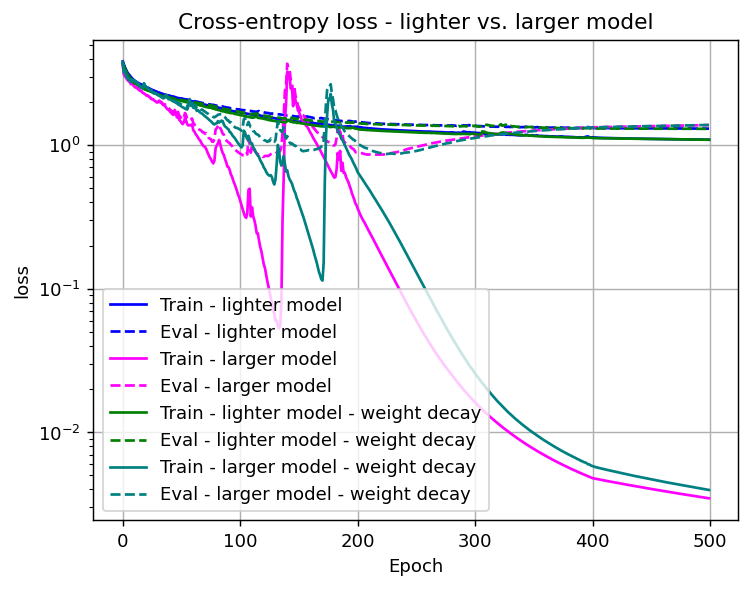

In [6]:
plt.figure(dpi = 130)
plt.title('Cross-entropy loss - lighter vs. larger model')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo1.epochs, trafo1.losses, color = 'blue', label = 'Train - lighter model')
plt.semilogy(trafo1.epochs, trafo1.losses_eval, '--', color = 'blue', label = 'Eval - lighter model')
plt.semilogy(trafo2.epochs, trafo2.losses, color = 'magenta', label = 'Train - larger model')
plt.semilogy(trafo2.epochs, trafo2.losses_eval, '--', color = 'magenta', label = 'Eval - larger model')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses, color = 'green', label = 'Train - lighter model - weight decay')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses_eval, '--', color = 'green', label = 'Eval - lighter model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses, color = 'teal', label = 'Train - larger model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses_eval, '--', color = 'teal', label = 'Eval - larger model - weight decay')
plt.legend()
plt.show()

def translate_string(word, model):
    encoded_input = encode_source(word).unsqueeze(0)
    generated_sequence = model.generate_sequence(encoded_input).cpu().squeeze()[1:-1] # exclude sos at beginning and eos at end

    return decode_source(generated_sequence)

In [7]:

# intermediate size
trafo3 = Transformer(n_layers = 2, d_model = 16, n_heads = 2, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 4, dv = 4, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

print('trafo3')
print(trafo3.count_parameters_by_module())
print('train trafo3')
trafo3.fit_from_txt("it_es_cognates.txt", n_epochs=500)

trafo2_120epochs = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
print('train trafo2_120epochs')
trafo2_120epochs.fit_from_txt("it_es_cognates.txt", n_epochs=120)

trafo3
{'embed': 592, 'pos_encoding': 0, 'encoder': 3376, 'decoder': 4544, 'exit_linear_projection': 629, 'criterion': 0, 'TOTAL': 9141}
train trafo3
Epoch  0 / 500  loss =  3.659853458404541  loss_eval =  3.667571544647217
Epoch  100 / 500  loss =  1.061853289604187  loss_eval =  1.2626641988754272
Epoch  200 / 500  loss =  0.5525729060173035  loss_eval =  0.8919668197631836
Epoch  300 / 500  loss =  0.339304655790329  loss_eval =  0.8788849711418152
Epoch  400 / 500  loss =  0.23206709325313568  loss_eval =  0.9301016330718994
train trafo2_120epochs
Epoch  0 / 120  loss =  3.65207576751709  loss_eval =  3.6507019996643066
Epoch  100 / 120  loss =  0.8373036980628967  loss_eval =  1.3003777265548706


In [8]:
italian_words = ["gatto", "nave", "croci", "croce", "dito", "stretta", "stretti", "stretto", "strette", "pensate", "lasagna", "passato"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]
expected_spanish_cognates_3 = [translate_string(word, trafo3) for word in italian_words]
expected_spanish_cognates_2_120ep = [translate_string(word, trafo2_120epochs) for word in italian_words]

print("Words in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output medium model':<20}| {'output larger model':<20} | {'output larger model 120 ep':<20}")
print("-" * 59)

for k in range(len(italian_words)):
     print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_3[k]:<20}| {expected_spanish_cognates_2[k]:<20}  | {expected_spanish_cognates_2_120ep[k]:<20}")
italian_words = ["parato", "parata", "parati", "parate", "ottone", "castoro", "matti", "passata", "passate", "passante", "incantato", "incantando"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]
expected_spanish_cognates_3 = [translate_string(word, trafo3) for word in italian_words]
expected_spanish_cognates_2_120ep = [translate_string(word, trafo2_120epochs) for word in italian_words]

print("Words not in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output medium model':<20}| {'output larger model':<20} | {'output larger model 120 ep':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_3[k]:<20}| {expected_spanish_cognates_2[k]:<20}  | {expected_spanish_cognates_2_120ep[k]:<20}")

Words in training dataset
Italian         | output light model   | output medium model | output larger model  | output larger model 120 ep
-----------------------------------------------------------
gatto           | juado                | gato                | gato                  | gato                
nave            | nave                 | nave                | nave                  | nave                
croci           | corovios             | croces              | cruces                | corico              
croce           | core                 | croce               | cruz                  | corre               
dito            | dido                 | decho               | dedo                  | dedo                
stretta         | estrada              | estrecha            | estrecha              | estrecha            
stretti         | estrado              | estrechos           | estrechos             | trestechos          
stretto         | estrado              | estr

Epoch  0 / 1000  loss =  3.8314571380615234  loss_eval =  3.815640449523926
Epoch  100 / 1000  loss =  1.716553807258606  loss_eval =  1.7932276725769043
Epoch  200 / 1000  loss =  1.3273141384124756  loss_eval =  1.4599961042404175
Epoch  300 / 1000  loss =  1.1940993070602417  loss_eval =  1.3480902910232544
Epoch  400 / 1000  loss =  1.1151080131530762  loss_eval =  1.296169400215149
Epoch  500 / 1000  loss =  1.0671555995941162  loss_eval =  1.2664272785186768
Epoch  600 / 1000  loss =  1.0405999422073364  loss_eval =  1.2453484535217285
Epoch  700 / 1000  loss =  1.0276309251785278  loss_eval =  1.2397572994232178
Epoch  800 / 1000  loss =  1.0163075923919678  loss_eval =  1.2335373163223267
Epoch  900 / 1000  loss =  1.0107697248458862  loss_eval =  1.2314198017120361
Epoch  0 / 1000  loss =  3.8647146224975586  loss_eval =  3.8684189319610596
Epoch  100 / 1000  loss =  1.0238741636276245  loss_eval =  1.2243125438690186
Epoch  200 / 1000  loss =  0.43517181277275085  loss_eval =

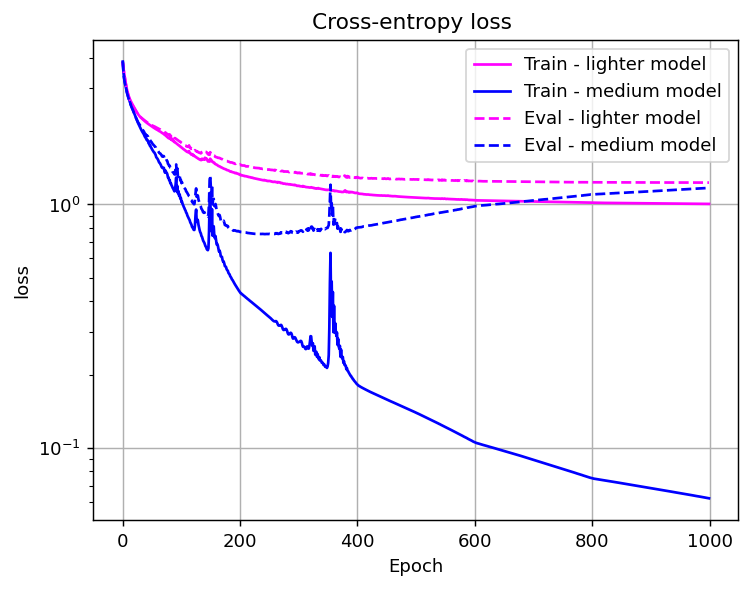

In [9]:
trafo1 = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
trafo1.fit_from_txt("it_es_cognates.txt", n_epochs=1000)
trafo3 = Transformer(n_layers = 2, d_model = 16, n_heads = 2, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 4, dv = 4, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
trafo3.fit_from_txt("it_es_cognates.txt", n_epochs=1000)

plt.figure(dpi = 130)
plt.title('Cross-entropy loss ')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo1.epochs, trafo1.losses, color = 'magenta', label = 'Train - lighter model')
plt.semilogy(trafo3.epochs, trafo3.losses, color = 'blue', label = 'Train - medium model')
plt.semilogy(trafo1.epochs, trafo1.losses_eval, '--', color = 'magenta', label = 'Eval - lighter model')
plt.semilogy(trafo1.epochs, trafo3.losses_eval, '--', color = 'blue', label = 'Eval - medium model')
plt.legend()
plt.show()

# basically, overfitting
works fine on training dataset but not very well on random words. especially with large model. in some cases the lmodels give ok results for words not in training dataset (such as lutti - luchos). Note that the Spanish must does not have to exist in reality! It is only a hypothetical words obtained by applying the phonetical correspoendence between the two languages

same phenomenon if I change the number of layers n_layers. using weight decay with lambda = 1e-2 does not seem to make much of a difference

for now, the medium size model seems to have the best results on words not in the training dataset

need bigger dataset, as I add more words the model get **slowly** better on the eval dataset/unknown words

**regularization: try dropout and change weight decay parameter**